In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Red mask detection, same logic as in laser_detector.py
def detect_laser_on_image(image):
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([179, 255, 255])

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = mask1 | mask2
    mask = cv2.medianBlur(mask, 5)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    center = None
    if contours:
        c = max(contours, key=cv2.contourArea)
        M = cv2.moments(c)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            center = (cx, cy)
            cv2.circle(image, center, 10, (0, 255, 0), -1)

    return image, center


In [ ]:
# Load test image
image_path = "../assets/images/Visor.jpg"
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError("Image non trouvée. Vérifie le chemin.")
    
# Redimensionner pour tests si besoin
image = cv2.resize(image, (640, 480))


In [ ]:
# Apply Laser detection
processed_image, center = detect_laser_on_image(image.copy())

if center:
    print(f"Centre détecté du spot laser : {center}")
else:
    print("Aucun spot laser détecté.")


Centre détecté du spot laser : (167, 238)


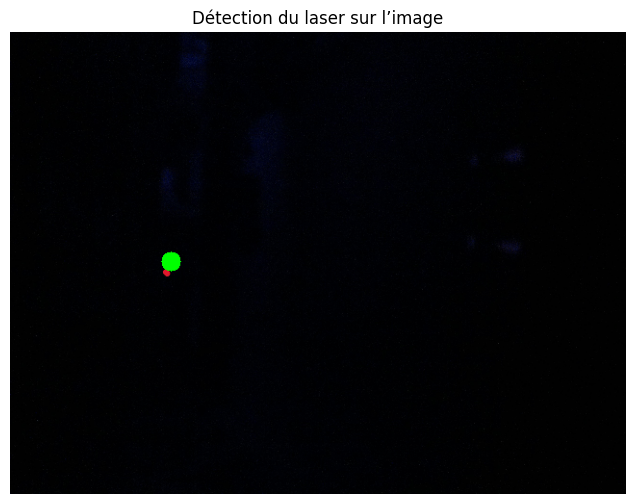

In [4]:
# OpenCV utilise BGR, matplotlib attend RGB
image_rgb = cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.title("Détection du laser sur l’image")
plt.axis("off")
plt.show()
